# Vehicle Insurance Premium Prediction

## Project Overview
This project builds a binary classification model to predict whether a vehicle insurance premium is greater than 300. The workflow includes data exploration, feature engineering, model training, evaluation, feature importance analysis, model simplification using the top 10 features, and deployment in Streamlit.

## 1. Data Loading and Initial Setup
In this section, the required Python libraries are imported and the insurance dataset is loaded for analysis and modeling.

In [4]:
# Libraries used

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

pd.set_option('display.max_columns', None)


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression


In [5]:
### Data Import

data = pd.read_csv("motor.csv", sep=";")
data.head(30)

,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,Max_products,Lapse,Date_lapse,Payment,Premium,Cost_claims_year,N_claims_year,N_claims_history,R_Claims_history,Type_risk,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight
0,1,05/11/2015,05/11/2015,05/11/2016,15/04/1956,20/03/1976,0,4,1,2,1,0,NaN,0,222.52,0.00,0,0,0.00,1,0,0,2004,80,599,7068.00,0,P,NaN,190
1,1,05/11/2015,05/11/2016,05/11/2017,15/04/1956,20/03/1976,0,4,1,2,1,0,NaN,0,213.78,0.00,0,0,0.00,1,0,0,2004,80,599,7068.00,0,P,NaN,190
2,1,05/11/2015,05/11/2017,05/11/2018,15/04/1956,20/03/1976,0,4,2,2,1,0,NaN,0,214.84,0.00,0,0,0.00,1,0,0,2004,80,599,7068.00,0,P,NaN,190
3,1,05/11/2015,05/11/2018,05/11/2019,15/04/1956,20/03/1976,0,4,2,2,1,0,NaN,0,216.99,0.00,0,0,0.00,1,0,0,2004,80,599,7068.00,0,P,NaN,190
4,2,26/09/2017,26/09/2017,26/09/2018,15/04/1956,20/03/1976,0,4,2,2,1,0,NaN,1,213.70,0.00,0,0,0.00,1,0,0,2004,80,599,7068.00,0,P,NaN,190
5,2,26/09/2017,26/09/2018,26/09/2019,15/04/1956,20/03/1976,0,4,2,2,1,0,NaN,1,215.83,0.00,0,0,0.00,1,0,0,2004,80,599,7068.00,0,P,NaN,190
6,3,29/11/2013,29/11/2015,29/11/2016,18/03/1975,10/07/1995,0,15,1,2,1,0,NaN,0,380.20,0.00,0,0,0.00,3,0,0,2013,85,1229,16030.00,5,P,3.999,1105
7,3,29/11/2013,29/11/2016,29/11/2017,18/03/1975,10/07/1995,0,15,1,2,1,0,NaN,0,393.50,0.00,0,0,0.00,3,0,0,2013,85,1229,16030.00,5,P,3.999,1105
8,3,29/11/2013,29/11/2017,29/11/2018,18/03/1975,10/07/1995,0,15,1,2,1,0,NaN,0,393.50,0.00,0,0,0.00,3,0,0,2013,85,1229,16030.00,5,P,3.999,1105
9,3,29/11/2013,29/11/2018,29/11/2019,18/03/1975,10/07/1995,0,15,1,2,1,0,NaN,0,395.47,0.00,0,0,0.00,3,0,0,2013,85,1229,16030.00,5,P,3.999,1105


In [6]:
## Data characteristics

data.shape

(105555, 30)

## 2. Exploratory Data Analysis
This section explores the dataset structure, variable types, summary statistics, and overall data quality. The goal is to understand the available features and identify any preprocessing needs before modeling.

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105555 entries, 0 to 105554
Data columns (total 30 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    105555 non-null  int64  
 1   Date_start_contract   105555 non-null  object 
 2   Date_last_renewal     105555 non-null  object 
 3   Date_next_renewal     105555 non-null  object 
 4   Date_birth            105555 non-null  object 
 5   Date_driving_licence  105555 non-null  object 
 6   Distribution_channel  105555 non-null  int64  
 7   Seniority             105555 non-null  int64  
 8   Policies_in_force     105555 non-null  int64  
 9   Max_policies          105555 non-null  int64  
 10  Max_products          105555 non-null  int64  
 11  Lapse                 105555 non-null  int64  
 12  Date_lapse            35147 non-null   object 
 13  Payment               105555 non-null  int64  
 14  Premium               105555 non-null  float64
 15  

In [8]:
round((data.isna().sum()/data.shape[0]) * 100,2)

ID                       0.00
Date_start_contract      0.00
Date_last_renewal        0.00
Date_next_renewal        0.00
Date_birth               0.00
Date_driving_licence     0.00
Distribution_channel     0.00
Seniority                0.00
Policies_in_force        0.00
Max_policies             0.00
Max_products             0.00
Lapse                    0.00
Date_lapse              66.70
Payment                  0.00
Premium                  0.00
Cost_claims_year         0.00
N_claims_year            0.00
N_claims_history         0.00
R_Claims_history         0.00
Type_risk                0.00
Area                     0.00
Second_driver            0.00
Year_matriculation       0.00
Power                    0.00
Cylinder_capacity        0.00
Value_vehicle            0.00
N_doors                  0.00
Type_fuel                1.67
Length                   9.79
Weight                   0.00
dtype: float64

In [9]:
## correcting dtypes
data["Date_start_contract"] = pd.to_datetime(data["Date_start_contract"],format="%d/%m/%Y")
data["Date_last_renewal"] = pd.to_datetime(data["Date_last_renewal"],format="%d/%m/%Y")
data["Date_next_renewal"] = pd.to_datetime(data["Date_next_renewal"],format="%d/%m/%Y")
data["Date_birth"] = pd.to_datetime(data["Date_birth"],format="%d/%m/%Y")
data["Date_driving_licence"] = pd.to_datetime(data["Date_driving_licence"],format="%d/%m/%Y")
data["Date_lapse"] = pd.to_datetime(data["Date_lapse"],format="%d/%m/%Y")

In [10]:
data.duplicated().sum()

np.int64(0)

In [11]:
data.dropna().head(30)

,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,Max_products,Lapse,Date_lapse,Payment,Premium,Cost_claims_year,N_claims_year,N_claims_history,R_Claims_history,Type_risk,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight
18,7,2015-02-11,2016-02-11,2017-02-11,1946-05-14,2000-03-24,1,3,1,1,1,0,2017-02-11,0,340.43,2162.89,3,4,2.00,3,0,0,2009,109,1396,16550.00,5,P,4.245,1168
22,9,2013-10-24,2016-10-24,2017-10-24,1949-10-22,1995-05-17,1,6,1,3,1,0,2017-10-24,0,259.12,0.00,0,2,0.50,3,0,1,2013,65,1870,13140.00,5,D,4.129,1125
23,9,2013-10-24,2017-10-24,2018-10-24,1949-10-22,1995-05-17,1,6,3,3,1,1,2017-10-24,0,214.34,0.00,0,2,0.50,3,0,1,2013,65,1870,13140.00,5,D,4.129,1125
28,12,2016-04-05,2016-04-05,2017-04-05,1946-06-04,1966-10-12,1,3,1,1,1,0,2018-04-05,1,474.49,297.32,8,8,4.00,2,0,1,2007,70,1248,13780.00,4,D,4.159,1295
29,12,2016-04-05,2017-04-05,2018-04-05,1946-06-04,1966-10-12,1,3,1,1,1,0,2018-04-05,1,483.98,440.96,4,8,4.00,2,0,1,2007,70,1248,13780.00,4,D,4.159,1295
30,12,2016-04-05,2018-04-05,2019-04-05,1946-06-04,1966-10-12,1,3,1,1,1,1,2018-04-05,1,488.81,0.00,0,8,4.00,2,0,1,2007,70,1248,13780.00,4,D,4.159,1295
31,13,2016-05-13,2016-05-13,2017-05-13,1951-02-16,1976-10-16,0,3,1,1,1,0,2018-05-13,0,248.68,0.00,0,0,0.00,3,1,0,2007,75,1390,8548.00,4,P,4.250,1050
32,13,2016-05-13,2017-05-13,2018-05-13,1951-02-16,1976-10-16,0,3,1,1,1,0,2018-05-13,0,257.39,0.00,0,0,0.00,3,1,0,2007,75,1390,8548.00,4,P,4.250,1050
33,13,2016-05-13,2018-05-13,2019-05-13,1951-02-16,1976-10-16,0,3,1,1,1,1,2018-05-13,0,254.81,0.00,0,0,0.00,3,1,0,2007,75,1390,8548.00,4,P,4.250,1050
55,22,2014-11-11,2015-11-11,2016-11-11,1944-04-01,1964-05-01,0,5,1,1,1,0,2018-11-11,0,274.61,0.00,0,1,0.25,3,0,0,2004,100,1896,15571.00,5,D,3.953,1165


In [12]:
to_drop = ["Date_lapse","Cost_claims_year", "N_claims_year","N_claims_history", "R_Claims_history", "ID"]


In [13]:
df1 = data.drop(to_drop, axis=1)
df1.dtypes

Date_start_contract     datetime64[ns]
Date_last_renewal       datetime64[ns]
Date_next_renewal       datetime64[ns]
Date_birth              datetime64[ns]
Date_driving_licence    datetime64[ns]
Distribution_channel             int64
Seniority                        int64
Policies_in_force                int64
Max_policies                     int64
Max_products                     int64
Lapse                            int64
Payment                          int64
Premium                        float64
Type_risk                        int64
Area                             int64
Second_driver                    int64
Year_matriculation               int64
Power                            int64
Cylinder_capacity                int64
Value_vehicle                  float64
N_doors                          int64
Type_fuel                       object
Length                         float64
Weight                           int64
dtype: object

In [14]:
df1 = df1.dropna(axis =0)

In [15]:
round((df1.isna().sum()/data.shape[0]) * 100,2)

Date_start_contract     0.0
Date_last_renewal       0.0
Date_next_renewal       0.0
Date_birth              0.0
Date_driving_licence    0.0
Distribution_channel    0.0
Seniority               0.0
Policies_in_force       0.0
Max_policies            0.0
Max_products            0.0
Lapse                   0.0
Payment                 0.0
Premium                 0.0
Type_risk               0.0
Area                    0.0
Second_driver           0.0
Year_matriculation      0.0
Power                   0.0
Cylinder_capacity       0.0
Value_vehicle           0.0
N_doors                 0.0
Type_fuel               0.0
Length                  0.0
Weight                  0.0
dtype: float64

In [16]:
df1.shape

(95226, 24)

In [17]:
## End year will be picked as 2019.

In [18]:
df1.head()

,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,Max_products,Lapse,Payment,Premium,Type_risk,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight
6,2013-11-29,2015-11-29,2016-11-29,1975-03-18,1995-07-10,0,15,1,2,1,0,0,380.20,3,0,0,2013,85,1229,16030.0,5,P,3.999,1105
7,2013-11-29,2016-11-29,2017-11-29,1975-03-18,1995-07-10,0,15,1,2,1,0,0,393.50,3,0,0,2013,85,1229,16030.0,5,P,3.999,1105
8,2013-11-29,2017-11-29,2018-11-29,1975-03-18,1995-07-10,0,15,1,2,1,0,0,393.50,3,0,0,2013,85,1229,16030.0,5,P,3.999,1105
9,2013-11-29,2018-11-29,2019-11-29,1975-03-18,1995-07-10,0,15,1,2,1,0,0,395.47,3,0,0,2013,85,1229,16030.0,5,P,3.999,1105
15,2006-05-29,2016-05-29,2017-05-29,1966-10-21,1990-09-10,0,13,1,2,2,0,0,250.52,3,0,0,2006,87,1598,9927.0,4,P,4.250,1055


In [19]:
df1.describe()

,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,Max_products,Lapse,Payment,Premium,Type_risk,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Length,Weight
count,95226,95226,95226,95226,95226,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000
mean,2014-06-23 00:20:19.431667712,2017-06-17 20:28:18.494108672,2018-06-17 22:38:51.346480896,1970-04-14 07:11:03.927918851,1992-11-24 17:24:47.316489216,0.458698,6.655336,1.419654,1.795518,1.048128,0.219908,0.347384,333.527729,2.864165,0.270136,0.136265,2005.195587,99.341524,1719.102724,19551.297720,4.462720,4.252007,1266.898137
min,1980-10-25 00:00:00,2015-11-02 00:00:00,2016-11-02 00:00:00,1918-04-05 00:00:00,1942-10-01 00:00:00,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,40.400000,1.000000,0.000000,0.000000,1953.000000,12.000000,125.000000,270.460000,0.000000,1.978000,137.000000
25%,2013-04-01 00:00:00,2016-09-04 00:00:00,2017-09-04 00:00:00,1961-01-15 00:00:00,1983-07-21 00:00:00,0.000000,3.000000,1.000000,1.000000,1.000000,0.000000,0.000000,254.810000,3.000000,0.000000,0.000000,2002.000000,75.000000,1422.000000,14270.080000,4.000000,3.999000,1089.000000
50%,2015-09-14 00:00:00,2017-07-05 00:00:00,2018-07-05 00:00:00,1970-11-09 00:00:00,1993-12-10 00:00:00,0.000000,4.000000,1.000000,1.000000,1.000000,0.000000,0.000000,301.650000,3.000000,0.000000,0.000000,2005.000000,98.000000,1665.000000,18330.870000,5.000000,4.230000,1239.000000
75%,2017-02-25 00:00:00,2018-04-04 00:00:00,2019-04-04 00:00:00,1980-04-25 00:00:00,2003-03-07 00:00:00,1.000000,9.000000,2.000000,2.000000,1.000000,0.000000,1.000000,370.710000,3.000000,1.000000,0.000000,2008.000000,112.000000,1956.000000,23000.000000,5.000000,4.443000,1399.000000
max,2018-11-30 00:00:00,2018-11-30 00:00:00,2019-11-30 00:00:00,2000-10-11 00:00:00,2018-11-26 00:00:00,1.000000,40.000000,17.000000,17.000000,4.000000,7.000000,1.000000,2993.340000,4.000000,1.000000,1.000000,2018.000000,580.000000,6788.000000,220675.800000,6.000000,8.218000,5455.000000
std,NaN,NaN,NaN,NaN,NaN,0.498294,6.212029,0.879651,1.108000,0.231117,0.460368,0.476142,134.341370,0.343380,0.444032,0.343072,5.678827,30.091550,409.410671,8219.591153,0.869386,0.393220,264.044713


In [20]:
df1["age"] = 2019 - df1["Date_birth"].dt.year
df1["year_licensed"] = 2019 - df1["Date_driving_licence"].dt.year
df1["car_age"] = 2019 - df1["Year_matriculation"]

to_drop2 =["Date_start_contract","Date_birth","Date_driving_licence", "Date_next_renewal", "Date_last_renewal", "Year_matriculation"]

df1 = df1.drop(to_drop2, axis=1)

In [21]:
## Verify seniority values

In [22]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95226 entries, 6 to 105554
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Distribution_channel  95226 non-null  int64  
 1   Seniority             95226 non-null  int64  
 2   Policies_in_force     95226 non-null  int64  
 3   Max_policies          95226 non-null  int64  
 4   Max_products          95226 non-null  int64  
 5   Lapse                 95226 non-null  int64  
 6   Payment               95226 non-null  int64  
 7   Premium               95226 non-null  float64
 8   Type_risk             95226 non-null  int64  
 9   Area                  95226 non-null  int64  
 10  Second_driver         95226 non-null  int64  
 11  Power                 95226 non-null  int64  
 12  Cylinder_capacity     95226 non-null  int64  
 13  Value_vehicle         95226 non-null  float64
 14  N_doors               95226 non-null  int64  
 15  Type_fuel             9

In [23]:
df1.describe()

,Distribution_channel,Seniority,Policies_in_force,Max_policies,Max_products,Lapse,Payment,Premium,Type_risk,Area,Second_driver,Power,Cylinder_capacity,Value_vehicle,N_doors,Length,Weight,age,year_licensed,car_age
count,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000,95226.000000
mean,0.458698,6.655336,1.419654,1.795518,1.048128,0.219908,0.347384,333.527729,2.864165,0.270136,0.136265,99.341524,1719.102724,19551.297720,4.462720,4.252007,1266.898137,49.202865,26.583255,13.804413
std,0.498294,6.212029,0.879651,1.108000,0.231117,0.460368,0.476142,134.341370,0.343380,0.444032,0.343072,30.091550,409.410671,8219.591153,0.869386,0.393220,264.044713,12.782255,12.394984,5.678827
min,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,40.400000,1.000000,0.000000,0.000000,12.000000,125.000000,270.460000,0.000000,1.978000,137.000000,19.000000,1.000000,1.000000
25%,0.000000,3.000000,1.000000,1.000000,1.000000,0.000000,0.000000,254.810000,3.000000,0.000000,0.000000,75.000000,1422.000000,14270.080000,4.000000,3.999000,1089.000000,39.000000,16.000000,11.000000
50%,0.000000,4.000000,1.000000,1.000000,1.000000,0.000000,0.000000,301.650000,3.000000,0.000000,0.000000,98.000000,1665.000000,18330.870000,5.000000,4.230000,1239.000000,49.000000,26.000000,14.000000
75%,1.000000,9.000000,2.000000,2.000000,1.000000,0.000000,1.000000,370.710000,3.000000,1.000000,0.000000,112.000000,1956.000000,23000.000000,5.000000,4.443000,1399.000000,58.000000,36.000000,17.000000
max,1.000000,40.000000,17.000000,17.000000,4.000000,7.000000,1.000000,2993.340000,4.000000,1.000000,1.000000,580.000000,6788.000000,220675.800000,6.000000,8.218000,5455.000000,101.000000,77.000000,66.000000


In [24]:
## correlation check with 

df1_corr = df1.corr(numeric_only=True)
df1_corr

,Distribution_channel,Seniority,Policies_in_force,Max_policies,Max_products,Lapse,Payment,Premium,Type_risk,Area,Second_driver,Power,Cylinder_capacity,Value_vehicle,N_doors,Length,Weight,age,year_licensed,car_age
Distribution_channel,1.000000,-0.277598,-0.057847,-0.121964,-0.067680,0.056417,0.081364,0.081587,-0.041841,0.140984,0.051228,0.019616,0.035221,0.020723,0.007815,0.050768,0.042862,-0.035861,-0.053267,-0.035511
Seniority,-0.277598,1.000000,0.025876,0.241914,0.221048,-0.064314,-0.171295,-0.070993,-0.009478,0.001672,-0.078553,-0.061969,-0.025191,-0.058219,-0.043236,-0.048144,-0.044039,0.196327,0.226801,0.103561
Policies_in_force,-0.057847,0.025876,1.000000,0.775061,0.057890,0.197834,0.050518,-0.050662,-0.048665,-0.045361,0.070416,0.036666,0.075918,0.082588,-0.022386,0.079602,0.084252,0.021158,0.038613,0.057969
Max_policies,-0.121964,0.241914,0.775061,1.000000,0.262791,0.176415,0.024031,-0.037896,-0.063262,-0.032869,0.039764,0.047970,0.087367,0.087161,-0.026240,0.092189,0.095449,0.074506,0.099532,0.058188
Max_products,-0.067680,0.221048,0.057890,0.262791,1.000000,0.015709,-0.017660,-0.012741,-0.007340,0.024453,-0.003113,0.015312,0.019306,0.017073,0.000332,0.015271,0.014075,0.084210,0.100674,0.017774
Lapse,0.056417,-0.064314,0.197834,0.176415,0.015709,1.000000,0.073990,0.065049,-0.007406,0.034577,-0.015062,-0.003849,0.051477,-0.003142,-0.046332,0.016269,0.010764,-0.017607,-0.024878,0.114471
Payment,0.081364,-0.171295,0.050518,0.024031,-0.017660,0.073990,1.000000,0.187958,0.018846,0.042264,0.029530,0.036117,0.027865,0.021526,-0.002354,0.037889,0.030398,-0.129584,-0.157946,-0.002497
Premium,0.081587,-0.070993,-0.050662,-0.037896,-0.012741,0.065049,0.187958,1.000000,0.012204,0.083524,0.107512,0.282626,0.123152,0.340708,0.030763,0.195998,0.216801,-0.100813,-0.090659,-0.287014
Type_risk,-0.041841,-0.009478,-0.048665,-0.063262,-0.007340,-0.007406,0.018846,0.012204,1.000000,0.017096,0.089820,0.080476,-0.264161,-0.015258,0.012498,-0.380859,-0.349044,-0.089693,-0.098756,-0.052539
Area,0.140984,0.001672,-0.045361,-0.032869,0.024453,0.034577,0.042264,0.083524,0.017096,1.000000,-0.006569,-0.006659,-0.026743,-0.010488,-0.021926,-0.010782,-0.018264,-0.022720,-0.029933,-0.020172


In [25]:
df1_corr["Premium"].sort_values()

car_age                -0.287014
age                    -0.100813
year_licensed          -0.090659
Seniority              -0.070993
Policies_in_force      -0.050662
Max_policies           -0.037896
Max_products           -0.012741
Type_risk               0.012204
N_doors                 0.030763
Lapse                   0.065049
Distribution_channel    0.081587
Area                    0.083524
Second_driver           0.107512
Cylinder_capacity       0.123152
Payment                 0.187958
Length                  0.195998
Weight                  0.216801
Power                   0.282626
Value_vehicle           0.340708
Premium                 1.000000
Name: Premium, dtype: float64

<Axes: >

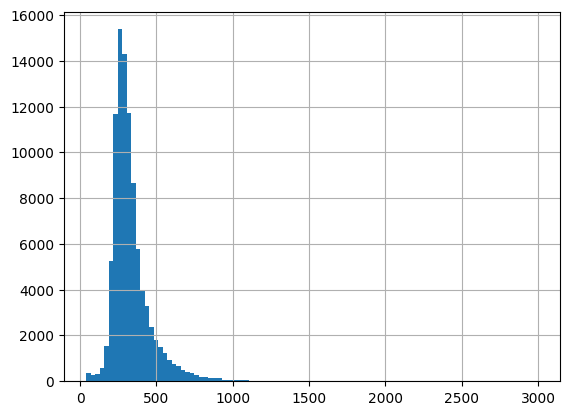

In [26]:
df1["Premium"].hist(bins=100)

<Axes: xlabel='Type_fuel', ylabel='count'>

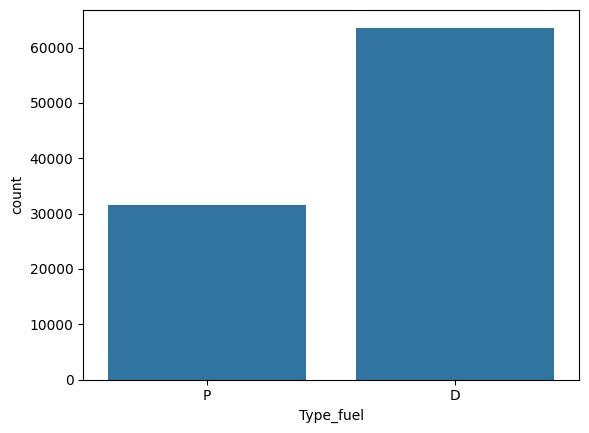

In [27]:
sns.countplot(x="Type_fuel", data=df1)

<Axes: xlabel='Premium'>

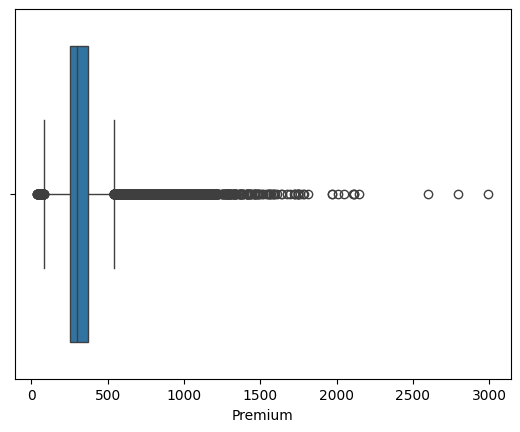

In [28]:
sns.boxplot(data=df1, x="Premium")

<Axes: xlabel='Premium', ylabel='Value_vehicle'>

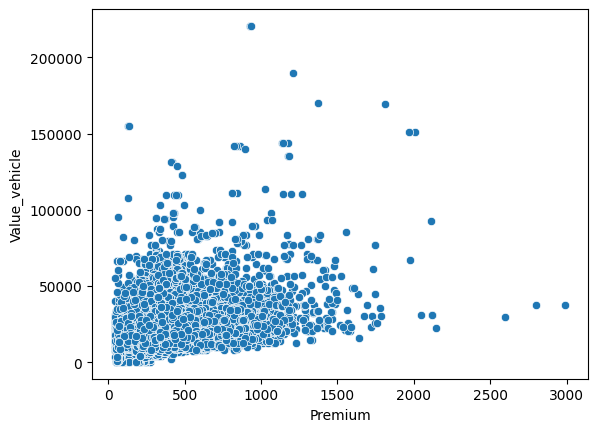

In [29]:
sns.scatterplot(data=df1, x="Premium", y="Value_vehicle")

<Axes: xlabel='Premium', ylabel='car_age'>

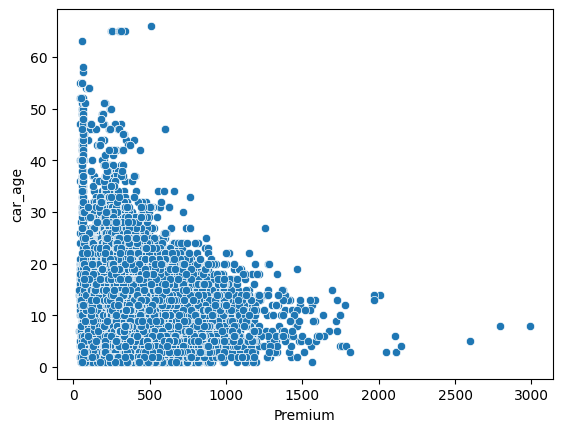

In [30]:
sns.scatterplot(data=df1, x="Premium", y="car_age")

<Axes: xlabel='Premium', ylabel='Power'>

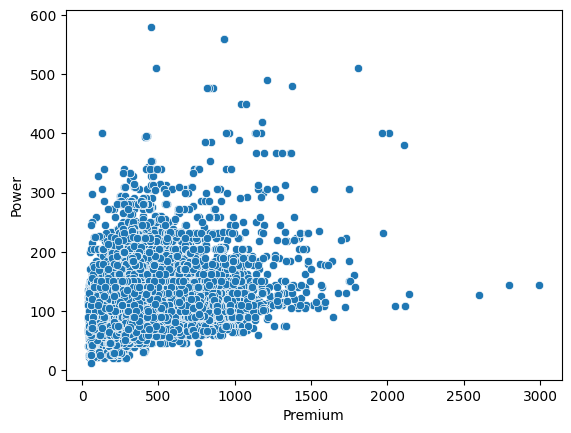

In [31]:
sns.scatterplot(data=df1, x="Premium", y="Power")

## 3. Target Engineering
The original `Premium` column is transformed into a binary target variable called `target_300`.

- `1` indicates that the premium is greater than 300
- `0` indicates that the premium is 300 or below

This converts the problem into a binary classification task suitable for supervised machine learning.

In [32]:
(df1["Premium"] > 300).value_counts(normalize=True)

Premium
True     0.508244
False    0.491756
Name: proportion, dtype: float64

In [33]:
#feature engineering

df1['target_300'] = (df1['Premium'] > 300).astype(int)
df1.drop("Premium", axis=1)

,Distribution_channel,Seniority,Policies_in_force,Max_policies,Max_products,Lapse,Payment,Type_risk,Area,Second_driver,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight,age,year_licensed,car_age,target_300
6,0,15,1,2,1,0,0,3,0,0,85,1229,16030.00,5,P,3.999,1105,44,24,6,1
7,0,15,1,2,1,0,0,3,0,0,85,1229,16030.00,5,P,3.999,1105,44,24,6,1
8,0,15,1,2,1,0,0,3,0,0,85,1229,16030.00,5,P,3.999,1105,44,24,6,1
9,0,15,1,2,1,0,0,3,0,0,85,1229,16030.00,5,P,3.999,1105,44,24,6,1
15,0,13,1,2,2,0,0,3,0,0,87,1598,9927.00,4,P,4.250,1055,53,29,13,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105550,0,1,1,1,1,0,0,3,0,0,110,1997,24320.00,5,D,4.740,1480,38,12,19,0
105551,0,1,1,1,1,0,0,3,0,0,129,1998,30861.97,5,P,4.650,1440,43,2,6,1
105552,0,1,1,1,1,0,1,3,0,0,55,999,7800.00,5,P,3.495,830,45,8,20,1
105553,0,1,1,1,1,0,0,2,0,0,90,1753,16610.00,5,D,4.555,1399,73,37,15,1


In [35]:
df1 = pd.get_dummies(df1, drop_first=False)

In [36]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95226 entries, 6 to 105554
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Distribution_channel  95226 non-null  int64  
 1   Seniority             95226 non-null  int64  
 2   Policies_in_force     95226 non-null  int64  
 3   Max_policies          95226 non-null  int64  
 4   Max_products          95226 non-null  int64  
 5   Lapse                 95226 non-null  int64  
 6   Payment               95226 non-null  int64  
 7   Premium               95226 non-null  float64
 8   Type_risk             95226 non-null  int64  
 9   Area                  95226 non-null  int64  
 10  Second_driver         95226 non-null  int64  
 11  Power                 95226 non-null  int64  
 12  Cylinder_capacity     95226 non-null  int64  
 13  Value_vehicle         95226 non-null  float64
 14  N_doors               95226 non-null  int64  
 15  Length                9

In [37]:
# Model Building

from sklearn.tree import plot_tree

def run_model(X_train, X_test, y_train, y_test):
    
    models = {
        "Logistic Regression": LogisticRegression(random_state=42, max_iter=5000),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "XGBoost": XGBClassifier(random_state=42)
}
    
    results= []
    
    for name, model in models.items():
        print(f"Model Training: {name}")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)  
        
        print(f"Accuracy: {acc:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")
        print("Confusion Matrix:")
        disp = ConfusionMatrixDisplay(cm, display_labels=['Below 300', 'Above 300'])
        disp.plot()
        plt.show()
        
        results.append({
            "Model": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1 Score": f1
        })
        
        
        if hasattr(model, "feature_importances_"):
            importances = model.feature_importances_
            feat_df = pd.DataFrame({
                'Feature': X_train.columns,
                'Importance': importances
            }).sort_values(by='Importance', ascending=False).head(10)

            plt.figure(figsize=(6, 4))
            sns.barplot(x='Importance', y='Feature', data=feat_df)
            plt.title(f"Top Features - {name}")
            plt.tight_layout()
            plt.show()
        
        if name == "Decision Tree":
            plt.figure(figsize=(20, 10))
            plot_tree(
                model, 
                feature_names=X_train.columns, 
                class_names=['Below 300', 'Above 300'],  # or '0', '1' if not binary labeled
                filled=True,
                rounded=True,
                max_depth=2
            )
            plt.title("Decision Tree Visualization (Top Levels)")
            plt.show()

        
        results_df = pd.DataFrame(results)
        print(f" " * 60)
        print(f" " * 60)
        print(f"*" * 60)
        print(f"*" * 60)

    return results_df

## 4. Feature Selection and Train-Test Split
In this section, the predictor matrix `X` is created by removing the target and original premium column. The data is then split into training and testing sets to evaluate model performance on unseen observations.

In [38]:
X = df1.drop(["target_300", "Premium"],axis=1)
y = df1["target_300"]

In [39]:

X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify = y, random_state=42)

In [40]:
y_train.shape

(71419,)

In [41]:
y_test.shape

(23807,)

In [42]:
y_test.value_counts(normalize=True)

target_300
1    0.508254
0    0.491746
Name: proportion, dtype: float64

## 5. Model Training and Evaluation
Multiple classification models are trained and evaluated using performance metrics such as accuracy, precision, recall, F1 score, ROC AUC, confusion matrix, and classification report. The purpose is to identify the model that provides the best balance of predictive performance and interpretability.

Model Training: Logistic Regression
Accuracy: 0.688 | Precision: 0.696 | Recall: 0.686 | F1: 0.691
Confusion Matrix:


/Users/chrisokoro/opt/anaconda3/envs/python311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


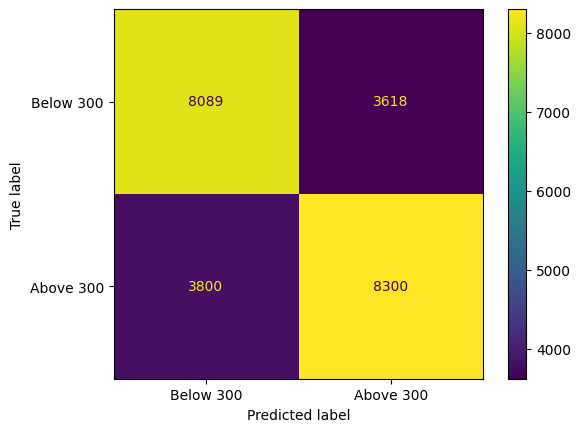

                                                            
                                                            
************************************************************
************************************************************
Model Training: Decision Tree
Accuracy: 0.792 | Precision: 0.805 | Recall: 0.781 | F1: 0.793
Confusion Matrix:


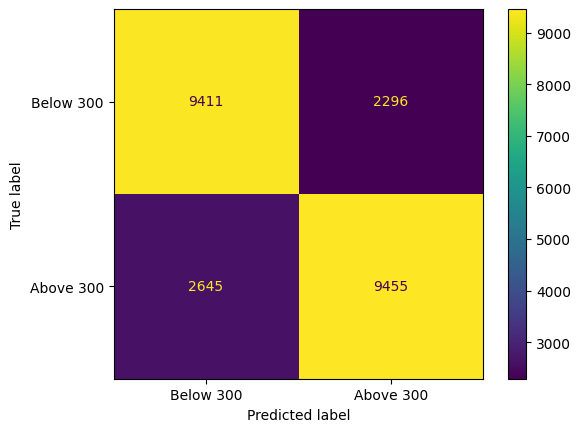

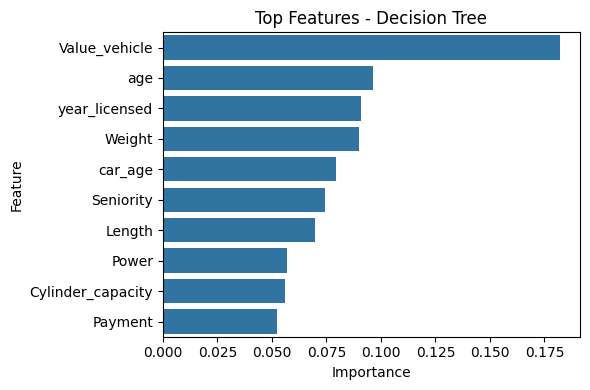

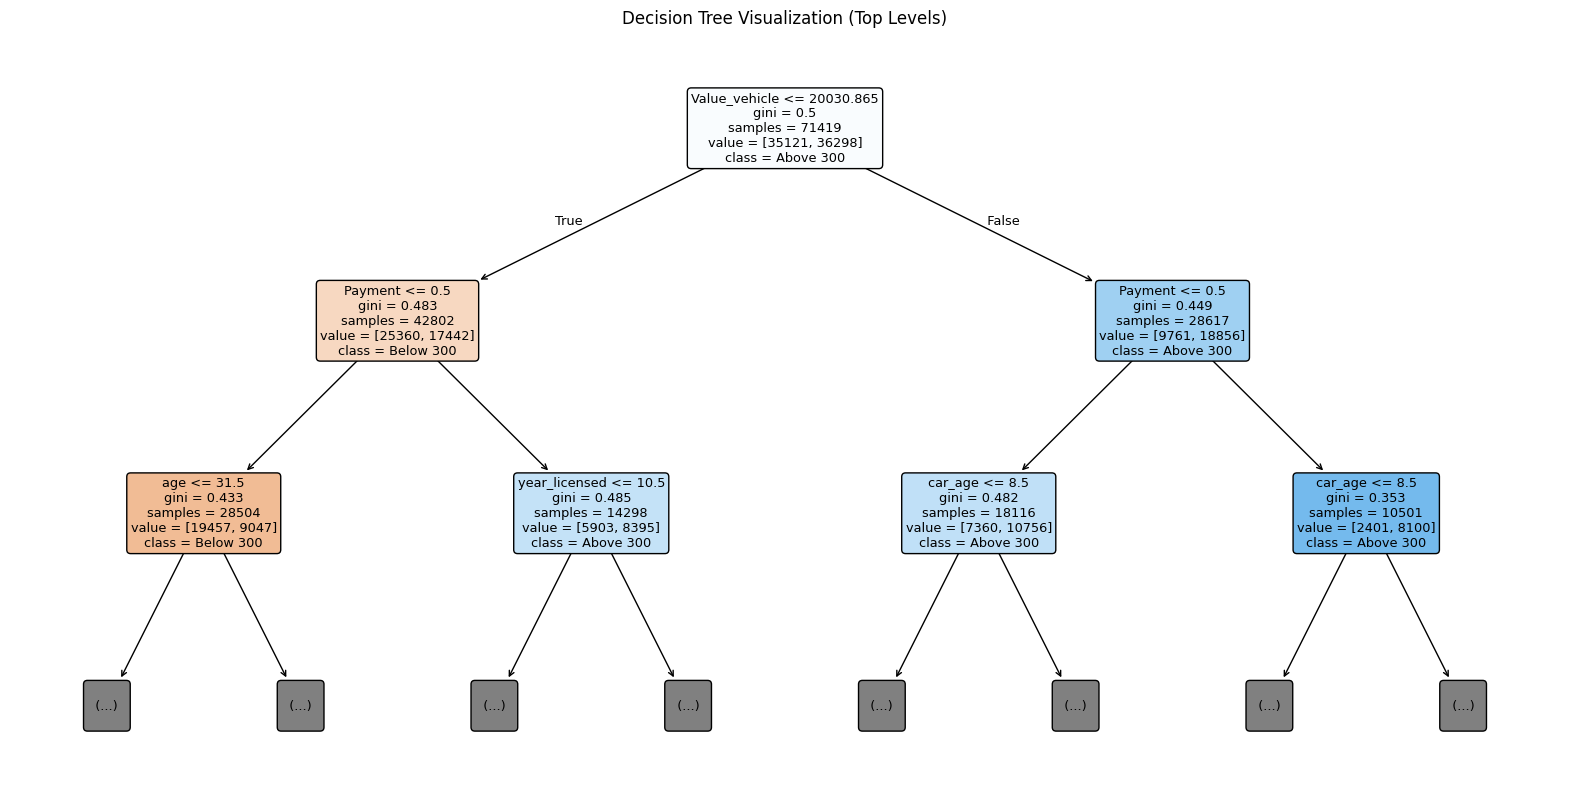

                                                            
                                                            
************************************************************
************************************************************
Model Training: Random Forest
Accuracy: 0.842 | Precision: 0.839 | Recall: 0.852 | F1: 0.846
Confusion Matrix:


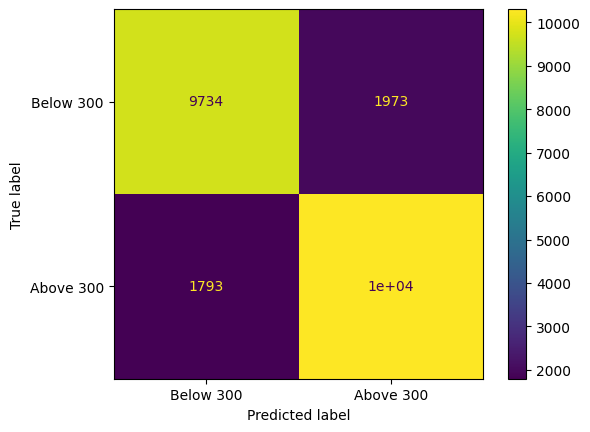

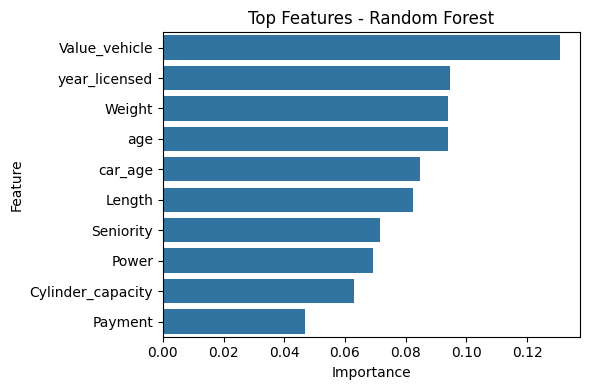

                                                            
                                                            
************************************************************
************************************************************
Model Training: XGBoost
Accuracy: 0.740 | Precision: 0.747 | Recall: 0.739 | F1: 0.743
Confusion Matrix:


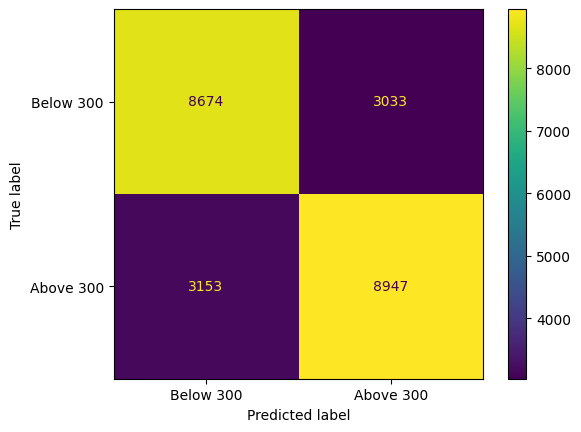

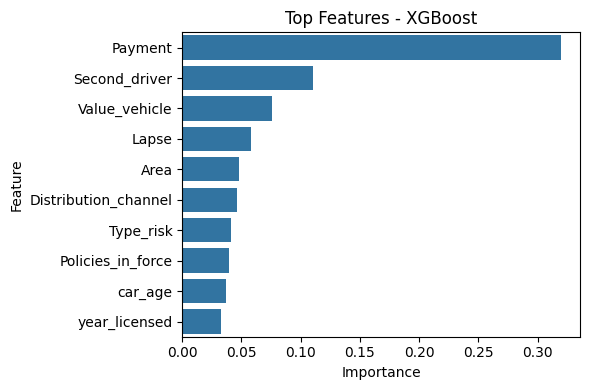

                                                            
                                                            
************************************************************
************************************************************
CPU times: user 1min 52s, sys: 27.7 s, total: 2min 20s
Wall time: 20.7 s


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.688411,0.696426,0.685950,0.691148
1,Decision Tree,0.792456,0.804612,0.781405,0.792839
2,Random Forest,0.841811,0.839332,0.851818,0.845529
3,XGBoost,0.740160,0.746828,0.739421,0.743106


In [43]:
%%time

run_model(X_train, X_test, y_train, y_test)

In [44]:
def run_model_cv(X_train, X_test, y_train, y_test):
    models = {
        "Decision Tree": {
            "estimator": DecisionTreeClassifier(random_state=42),
            "params": {
                'max_depth': [3,5,7, None], 
                'max_features': [1.0],
                'min_samples_leaf': [1,2,3,4],
                'min_samples_split': [2,3,4,5],
            } 
        },
        "Random Forest": {
            "estimator": RandomForestClassifier(random_state=42),
            "params": {
                'n_estimators': [50,100,200], 
                'max_depth': [10,50,100],        
                'min_samples_leaf': [1,2],
                'min_samples_split': [2,5],
                'max_features': ["sqrt"], 
                'max_samples': [0.5,0.9]
            }
        },
        "XGBoost": {
            "estimator": XGBClassifier(random_state=42),
            "params": {
                'max_depth': [1,3,5,7],
                'learning_rate': [0.01,0.1],
                'min_child_weight': [1,3,5,7],
                'n_estimators': [50,100,200,300],
            }
        }
    }

    results = []
    fitted_models = {}

    for name, model in models.items():
        print(f"Model Training: {name}")
        
        grid = GridSearchCV(
            estimator=model["estimator"],
            param_grid=model["params"],
            cv=5,
            scoring="f1",
            verbose=1
        )
        
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        fitted_models[name] = best_model
        
        y_pred = best_model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        results.append({
            "Model": name,
            "Best Params": grid.best_params_,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1 Score": f1
        })

        if hasattr(best_model, "feature_importances_"):
            importances = best_model.feature_importances_
            feat_df = pd.DataFrame({
                'Feature': X_train.columns,
                'Importance': importances
            }).sort_values(by='Importance', ascending=False).head(10)

            plt.figure(figsize=(6, 4))
            sns.barplot(x='Importance', y='Feature', data=feat_df)
            plt.title(f"Top Features - {name}")
            plt.tight_layout()
            plt.show()

    results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)
    best_model_name = results_df.iloc[0]["Model"]
    overall_best_model = fitted_models[best_model_name]

    return results_df, overall_best_model

Model Training: Decision Tree
Fitting 5 folds for each of 64 candidates, totalling 320 fits


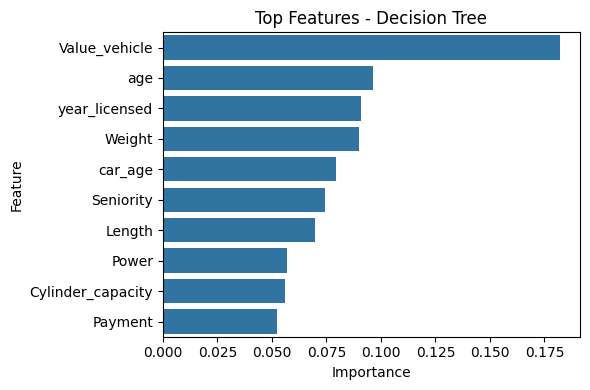

Model Training: Random Forest
Fitting 5 folds for each of 72 candidates, totalling 360 fits


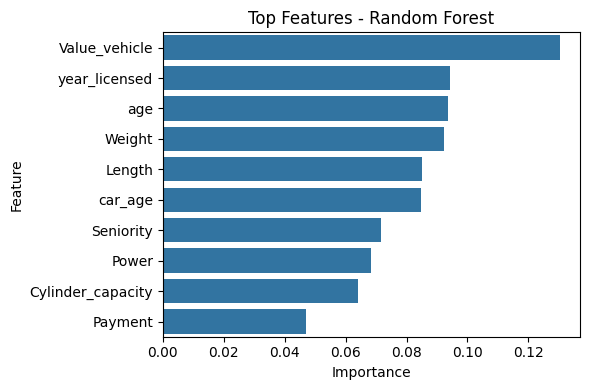

Model Training: XGBoost
Fitting 5 folds for each of 128 candidates, totalling 640 fits


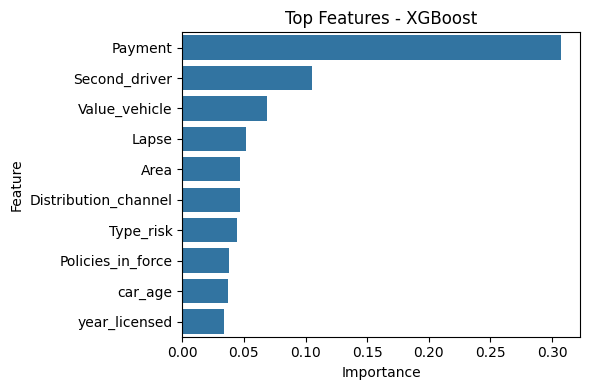

           Model                                        Best Params  Accuracy  \
1  Random Forest  {'max_depth': 50, 'max_features': 'sqrt', 'max...  0.841433   
0  Decision Tree  {'max_depth': None, 'max_features': 1.0, 'min_...  0.792456   
2        XGBoost  {'learning_rate': 0.1, 'max_depth': 7, 'min_ch...  0.757340   

   Precision    Recall  F1 Score  
1   0.837893  0.853058  0.845407  
0   0.804612  0.781405  0.792839  
2   0.764760  0.754711  0.759702  


In [45]:
results_df, best_model = run_model_cv(X_train, X_test, y_train, y_test)
print(results_df)

## 6. Feature Importance Analysis
Feature importance is used to identify which variables most strongly influence whether a premium falls above or below the threshold. This step helps improve model interpretability and supports feature reduction for deployment.

In [46]:
def plot_feature_importance(model, X, top_n=10, title="Feature Importance"):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_

        feat_df = pd.DataFrame({
            "Feature": X.columns,
            "Importance": importances
        }).sort_values("Importance", ascending=False).head(top_n)

        plt.figure(figsize=(8, 5))
        sns.barplot(data=feat_df, x="Importance", y="Feature")
        plt.title(title)
        plt.tight_layout()
        plt.show()

        return feat_df
    else:
        print("This model does not support feature_importances_.")
        return None

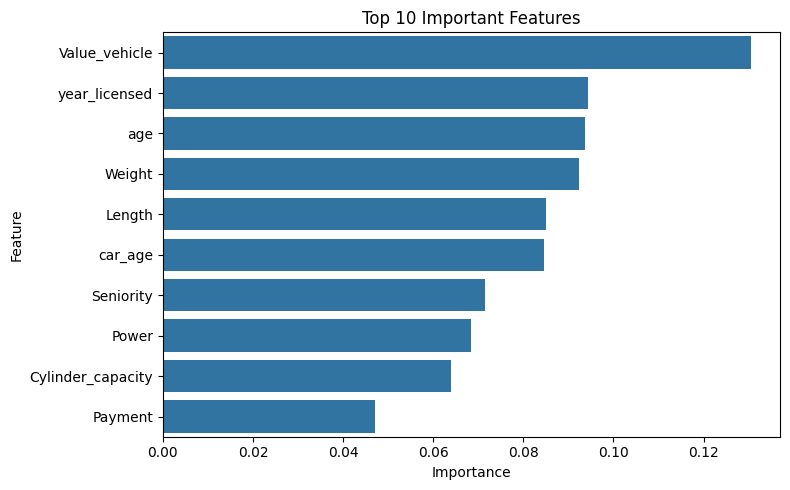

,Feature,Importance
12,Value_vehicle,0.130441
17,year_licensed,0.094292
16,age,0.093746
15,Weight,0.092330
14,Length,0.084961
18,car_age,0.084608
1,Seniority,0.071467
10,Power,0.068436
11,Cylinder_capacity,0.063975
6,Payment,0.047128


In [47]:
plot_feature_importance(best_model, X_train, top_n=10, title="Top 10 Important Features")

In [48]:
best_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",50
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [77]:
# import joblib

# joblib.dump(best_model, "random_forest_insurance_model.pkl")

['random_forest_insurance_model.pkl']

In [50]:
# joblib.dump(X_train.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

## 7. Reduced Model Using Top 10 Features
To improve usability in deployment, a reduced Random Forest model is trained using only the 10 most important features. Its performance is then compared with the full-feature Random Forest model to determine whether a simpler user interface can be used without sacrificing much predictive accuracy.

In [51]:
top_10_features = [
    "Value_vehicle",
    "Weight",
    "year_licensed",
    "age",
    "Length",
    "car_age",
    "Seniority",
    "Power",
    "Cylinder_capacity",
    "Payment"
]

X_top10 = df1[top_10_features]
y = df1["target_300"]

In [52]:
X_train_10, X_test_10, y_train, y_test = train_test_split(
    X_top10, y, test_size=0.2, random_state=42, stratify=y
)

In [53]:
rf_top10 = RandomForestClassifier(
    max_depth=50,
    max_features='sqrt',
    max_samples=0.9,
    n_estimators=200,
    random_state=42
)

rf_top10.fit(X_train_10, y_train)

y_pred_10 = rf_top10.predict(X_test_10)

print("Accuracy:", accuracy_score(y_test, y_pred_10))
print("Precision:", precision_score(y_test, y_pred_10))
print("Recall:", recall_score(y_test, y_pred_10))
print("F1:", f1_score(y_test, y_pred_10))
print(confusion_matrix(y_test, y_pred_10))

Accuracy: 0.8465294550036753
Precision: 0.8450617914411194
Recall: 0.8547520661157024
F1: 0.8498793076883571
[[7849 1517]
 [1406 8274]]


In [54]:
rf_top10

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",50
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. Define full feature set
# -----------------------------
X_full = df1.drop(["target_300", "Premium"], axis=1)
y = df1["target_300"]

# -----------------------------
# 2. Define top 10 feature set
# -----------------------------
top_10_features = [
    "Value_vehicle",
    "Weight",
    "year_licensed",
    "age",
    "Length",
    "car_age",
    "Seniority",
    "Power",
    "Cylinder_capacity",
    "Payment"
]

X_top10 = df1[top_10_features]

# -----------------------------
# 3. Train-test split
# Use same random_state so both are comparable
# -----------------------------
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

X_train_top10, X_test_top10, _, _ = train_test_split(
    X_top10, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 4. Define same RF settings
# -----------------------------
rf_params = {
    "max_depth": 50,
    "max_features": "sqrt",
    "max_samples": 0.9,
    "n_estimators": 200,
    "random_state": 42
}

rf_full = RandomForestClassifier(**rf_params)
rf_top10 = RandomForestClassifier(**rf_params)

# -----------------------------
# 5. Train models
# -----------------------------
rf_full.fit(X_train_full, y_train)
rf_top10.fit(X_train_top10, y_train)

# -----------------------------
# 6. Evaluation function
# -----------------------------
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    }

    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"{'='*60}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return results

# -----------------------------
# 7. Compare both models
# -----------------------------
results = []

results.append(evaluate_model(rf_full, X_test_full, y_test, "Random Forest - Full Features"))
results.append(evaluate_model(rf_top10, X_test_top10, y_test, "Random Forest - Top 10 Features"))

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by="F1 Score", ascending=False)

print("\nFinal Comparison Table:")
display(comparison_df)


Random Forest - Full Features
Confusion Matrix:
[[7795 1571]
 [1367 8313]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      9366
           1       0.84      0.86      0.85      9680

    accuracy                           0.85     19046
   macro avg       0.85      0.85      0.85     19046
weighted avg       0.85      0.85      0.85     19046


Random Forest - Top 10 Features
Confusion Matrix:
[[7849 1517]
 [1406 8274]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      9366
           1       0.85      0.85      0.85      9680

    accuracy                           0.85     19046
   macro avg       0.85      0.85      0.85     19046
weighted avg       0.85      0.85      0.85     19046


Final Comparison Table:


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Random Forest - Top 10 Features,0.846529,0.845062,0.854752,0.849879,0.916367
0,Random Forest - Full Features,0.845742,0.841056,0.858781,0.849826,0.920597



The Random Forest model trained on the top 10 most important features was selected for deployment. Although the full-feature Random Forest model performed similarly, the reduced model achieved nearly identical results while making the Streamlit interface cleaner and easier to use.

This made it the better choice for deployment, since users only need to enter the most influential features instead of the full set of inputs.

In [57]:


joblib.dump(rf_top10, "random_forest_top10_model.pkl")
joblib.dump(top_10_features, "top10_model_columns.pkl")

['top10_model_columns.pkl']

The final trained model and the list of input columns are saved using `joblib`. These files are later loaded into the Streamlit application for real-time predictions.

In [72]:
sample_data = X_top10.sample(n=15)

In [73]:
X_top10

,Value_vehicle,Weight,year_licensed,age,Length,car_age,Seniority,Power,Cylinder_capacity,Payment
6,16030.00,1105,24,44,3.999,6,15,85,1229,0
7,16030.00,1105,24,44,3.999,6,15,85,1229,0
8,16030.00,1105,24,44,3.999,6,15,85,1229,0
9,16030.00,1105,24,44,3.999,6,15,85,1229,0
15,9927.00,1055,29,53,4.250,13,13,87,1598,0
...,...,...,...,...,...,...,...,...,...,...
105550,24320.00,1480,12,38,4.740,19,1,110,1997,0
105551,30861.97,1440,2,43,4.650,6,1,129,1998,0
105552,7800.00,830,8,45,3.495,20,1,55,999,1
105553,16610.00,1399,37,73,4.555,15,1,90,1753,0


In [74]:
sample_data

,Value_vehicle,Weight,year_licensed,age,Length,car_age,Seniority,Power,Cylinder_capacity,Payment
77812,16270.00,1095,13,33,4.052,5,1,90,1598,0
95449,13090.04,1185,23,44,4.020,22,5,100,1598,1
88926,19304.81,1245,33,74,4.550,12,1,99,1975,1
2477,19970.00,1340,40,71,4.470,7,22,120,1598,0
16594,12990.00,1205,27,54,4.157,4,19,75,1499,0
71216,23048.81,1955,20,45,4.925,18,4,126,2902,1
38526,18450.00,1200,29,58,4.260,12,1,110,1587,1
63382,17750.00,1205,22,40,4.302,10,4,100,1598,0
66752,17350.00,1182,18,38,4.274,13,1,90,1360,0
90677,30990.00,1891,14,33,4.496,8,3,110,2499,0


In [75]:
sample_data.to_csv("sample_data.csv")

The sample_data above was used to test the streamlit batch csv process.

## 10. Deployment Summary
The final model was deployed in a Streamlit application that allows users to:

- enter the top 10 input features manually for a single prediction
- upload a CSV file for batch prediction
- view the predicted premium class along with class probabilities

This completes the end-to-end workflow from raw data to deployed machine learning application.